##1. Imports

In [18]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pre-processing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

# Model selection and evaluation metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

SEED=42;
TARGET='covid_vaccine';
ID='respondent_id'

##2. Loading Data

In [22]:
train=pd.read_csv('dataset_C_training.csv')
y=train[TARGET].values
print('train',train.shape)
train.head()

train (4756, 31)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [23]:
df.head()

,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4756 entries, 1 to 4756
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   covid_concern                 4744 non-null   float64
 1   covid_knowledge               4729 non-null   float64
 2   behavioral_antiviral_meds     4742 non-null   float64
 3   behavioral_avoidance          4729 non-null   float64
 4   behavioral_face_mask          4754 non-null   float64
 5   behavioral_wash_hands         4747 non-null   float64
 6   behavioral_large_gatherings   4746 non-null   float64
 7   behavioral_outside_home       4742 non-null   float64
 8   behavioral_touch_face         4735 non-null   float64
 9   chronic_med_condition         4587 non-null   float64
 10  child_under_6_months          4621 non-null   float64
 11  health_worker                 4624 non-null   float64
 12  health_insurance              2848 non-null   float64
 13  age_grou

##3. Exploratory Data Analysis

- Target Balance

Class counts: {0: 3202, 1: 1554}
Positive rate: 0.327


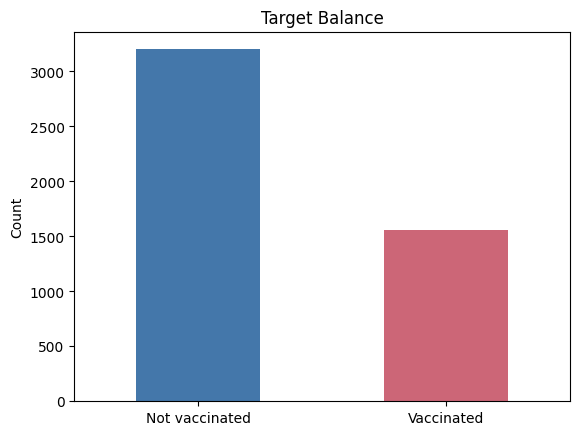

In [25]:
# Get the exact counts and the positive rate
target_counts = pd.Series(y).value_counts()
positive_rate = y.mean()

# Print the counts and the positive rate
print(f"Class counts: {target_counts.to_dict()}")
print(f"Positive rate: {positive_rate:.3f}")

# Plot the balance of the target variable using the hex colors
target_counts.sort_index().plot(kind='bar', color=['#4477aa', '#cc6677'])

# Add labels and title to the chart
plt.xticks([0, 1], ['Not vaccinated', 'Vaccinated'], rotation=0)
plt.ylabel('Count')
plt.title('Target Balance')

# Display the plot
plt.show()

- Missing Values

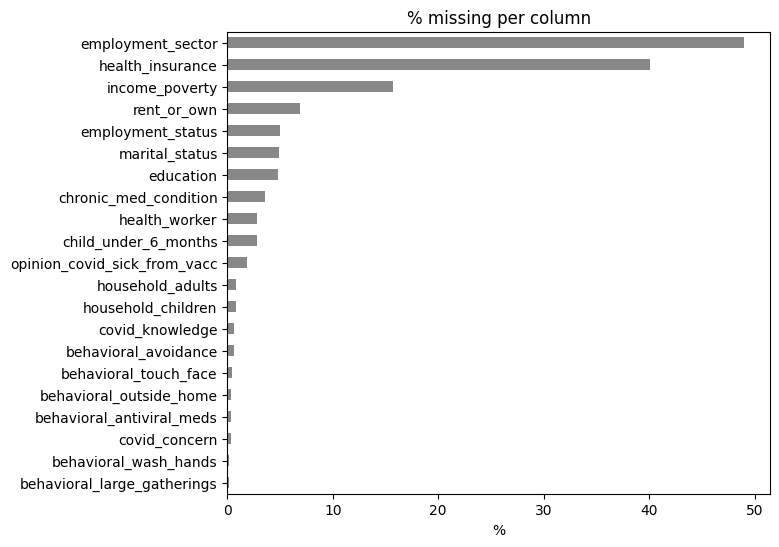

In [26]:
# Calculate the percentage of missing values for each column
missing_pct = (train.isna().mean() * 100).round(1)

# Keep only the columns that actually have missing data and sort them
missing_pct = missing_pct[missing_pct > 0].sort_values()

# Create a horizontal bar chart
missing_pct.plot(kind='barh', figsize=(7, 6), color='#888')

# Add title and x-axis label
plt.title('% missing per column')
plt.xlabel('%')

# Display the plot
plt.show()